In [2]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import cv2

from roifile import roiread
from persim import plot_diagrams

print("Packages loaded successfully!")

Packages loaded successfully!


Image is 500 wide and 415 tall
[[252. 255.]
 [252. 255.]
 [245. 255.]
 [242. 248.]
 [238. 255.]
 [235. 255.]
 [235. 255.]
 [223. 249.]
 [223. 255.]
 [210. 215.]
 [208. 255.]
 [207. 255.]
 [207. 241.]
 [203. 237.]
 [201. 255.]
 [199. 255.]
 [197. 212.]
 [196. 204.]
 [183. 188.]
 [175. 255.]
 [167. 208.]
 [160. 199.]
 [160. 165.]
 [159. 240.]
 [153. 162.]
 [150. 201.]
 [148. 231.]
 [142. 212.]
 [141. 255.]
 [140. 174.]
 [133. 193.]
 [131. 250.]
 [114. 160.]
 [114. 120.]
 [101. 255.]
 [100. 151.]
 [ 98. 150.]
 [ 96. 102.]
 [ 83. 144.]
 [ 81. 122.]
 [ 80. 124.]
 [ 65. 156.]
 [ 64.  71.]
 [ 64. 102.]
 [ 61.  81.]
 [ 61.  71.]
 [ 61.  77.]
 [ 61.  71.]
 [ 60.  95.]
 [ 58. 221.]
 [ 56.  62.]
 [ 55.  72.]
 [ 55.  82.]
 [ 53.  61.]
 [ 53.  83.]
 [ 51.  62.]
 [ 51.  78.]
 [ 51.  68.]
 [ 51.  92.]
 [ 51. 135.]
 [ 50.  67.]
 [ 49.  61.]
 [ 49. 225.]
 [ 48. 255.]
 [ 47.  61.]
 [ 47.  53.]
 [ 47.  94.]
 [ 46.  71.]
 [ 45.  79.]
 [ 45. 139.]
 [ 42. 255.]
 [ 42. 116.]
 [ 41.  64.]
 [ 40.  48.]
 [ 40. 

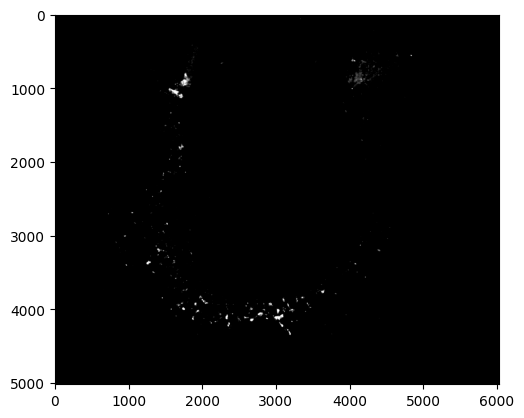

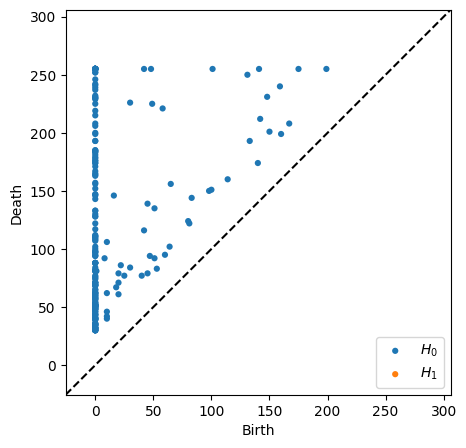

Image is 500 wide and 620 tall
[[254. 255.]
 [254. 255.]
 [253. 255.]
 ...
 [  0. 255.]
 [  0.  25.]
 [  0.  47.]]
Number of components before: 2018
Number of components after filtering: 1124
Number of cycles before: 63
Number of cycles after filtering: 15


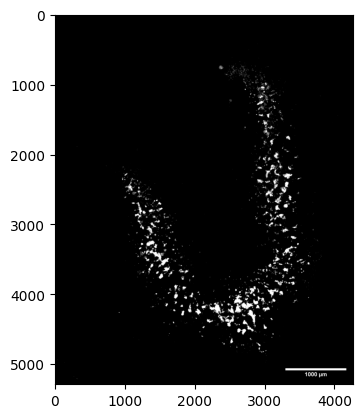

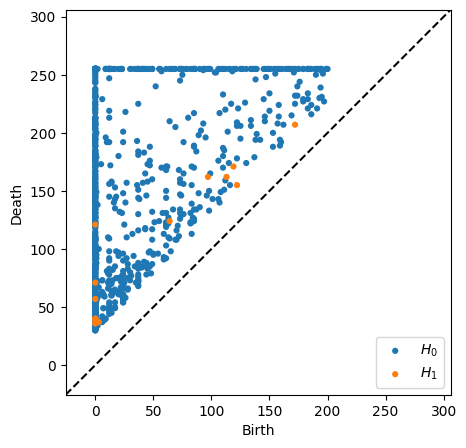

Image is 500 wide and 550 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   4.]
 [  0.  48.]
 [  0.   2.]]
Number of components before: 2993
Number of components after filtering: 1501
Number of cycles before: 169
Number of cycles after filtering: 45


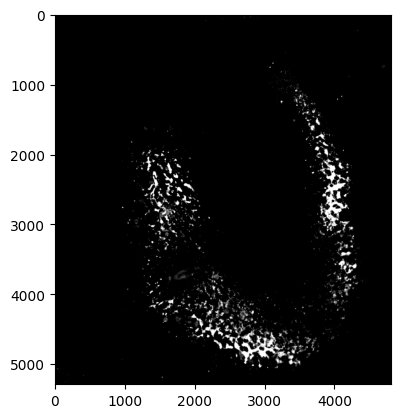

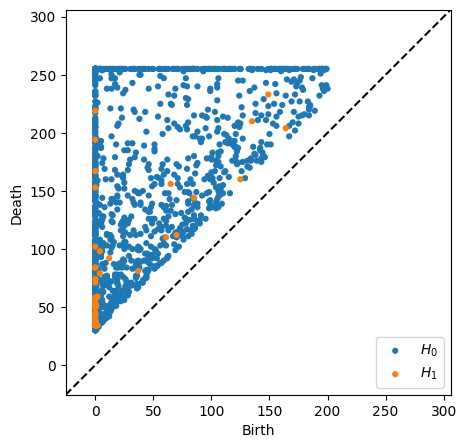

Image is 500 wide and 586 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   2.]
 [  0. 105.]
 [  0.  58.]]
Number of components before: 2902
Number of components after filtering: 976
Number of cycles before: 246
Number of cycles after filtering: 57


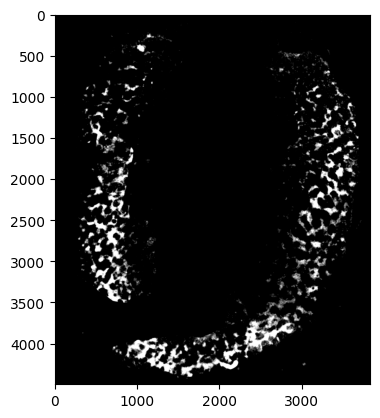

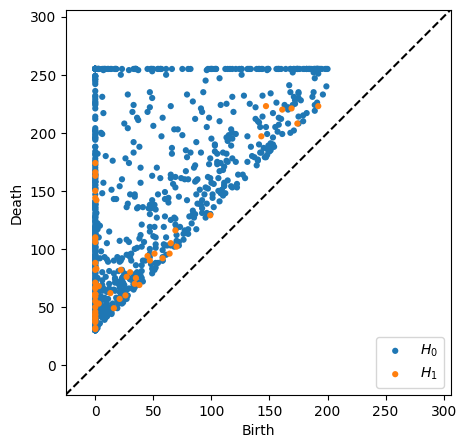

Image is 500 wide and 621 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   3.]
 [  0.   2.]
 [  0.   1.]]
Number of components before: 11618
Number of components after filtering: 1230
Number of cycles before: 3575
Number of cycles after filtering: 213


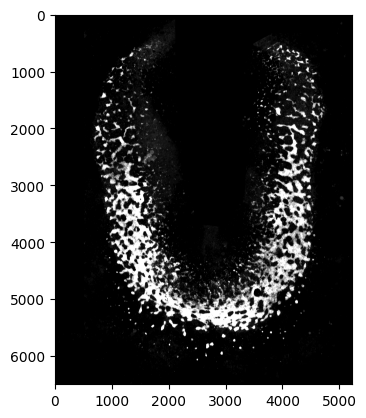

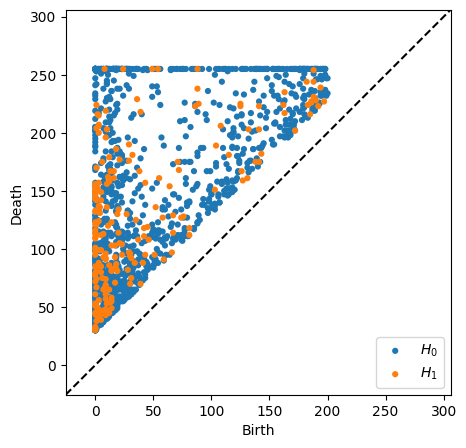

Image is 500 wide and 623 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   2.]
 [  0.   1.]
 [  0.  25.]]
Number of components before: 1100
Number of components after filtering: 536
Number of cycles before: 365
Number of cycles after filtering: 180


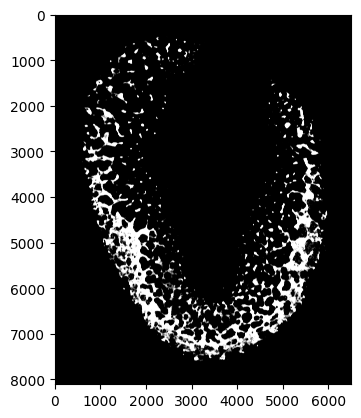

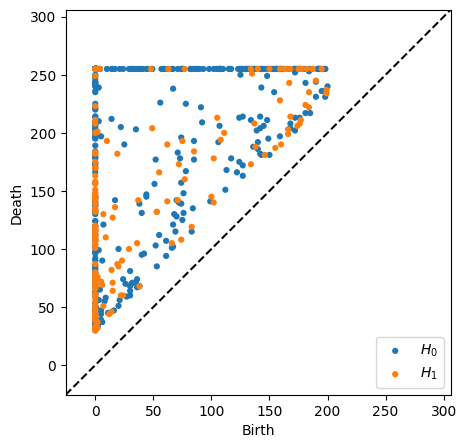

Image is 500 wide and 563 tall
[[254. 255.]
 [254. 255.]
 [253. 255.]
 ...
 [  0.  28.]
 [  0.   9.]
 [  0.  27.]]
Number of components before: 4429
Number of components after filtering: 936
Number of cycles before: 616
Number of cycles after filtering: 113


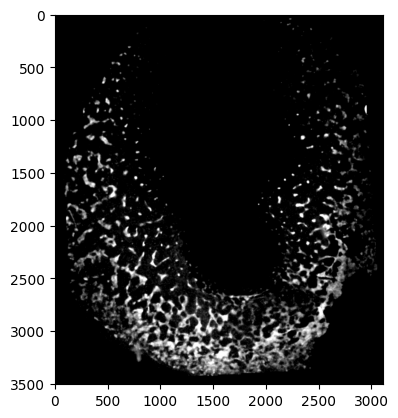

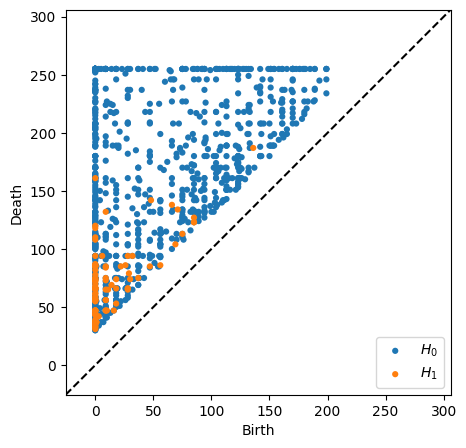

Image is 500 wide and 793 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.  78.]
 [  0.   8.]
 [  0.   5.]]
Number of components before: 892
Number of components after filtering: 481
Number of cycles before: 148
Number of cycles after filtering: 75


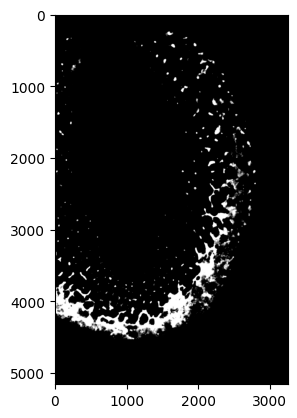

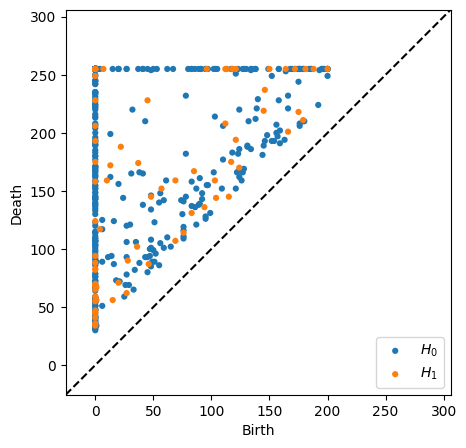

In [10]:
n=1
path = f"data/PH scaled/{n}"
stages = [3,4,5,6,8,10,11,12]
new_width = 500

weak_components_hh = []
strong_components_hh = []
weak_edges_hh = []
strong_edges_hh = []
components_hh = []
cycles_hh = []

for stage in stages:
    #image = cv2.imread(f'data/ph_test_cycles.png') #test image
    image = cv2.imread(f'data/PH scaled/{n}/hh{stage}BCblur.png')
    background_colour = "black"

    height = len(image)
    width = len(image[0])

    new_height = int(new_width/width * height)
    plt.imshow(image)
    image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
    if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
        image = 255-image

    grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(f"Image is {len(image[0])} wide and {len(image)} tall")
    #print(np.max(grey_image))



    #run PH
    result = ms.topology.level_set_filtration(grey_image) 
     
    fig,ax=plt.subplots(figsize=(5,5))

    cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
    components = result["dgms"][1]

    cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
    #print(components)
    #print("\n")
    #print(cycles)

    #plot_diagrams([components, cycles], show=True)
    # plot_diagrams([cycles], show=True)

    [components,cycles] = basic_filtering(components,cycles,plot=True)
    components_hh.append(len(components))
    cycles_hh.append(len(cycles))

    [n_weak_components,n_strong_components] = component_filtering(components)
    weak_components_hh.append(n_weak_components)
    strong_components_hh.append(n_strong_components)
    
    [n_weak_edges,n_strong_edges] = edge_filtering(components)
    weak_edges_hh.append(n_weak_edges)
    strong_edges_hh.append(n_strong_edges)


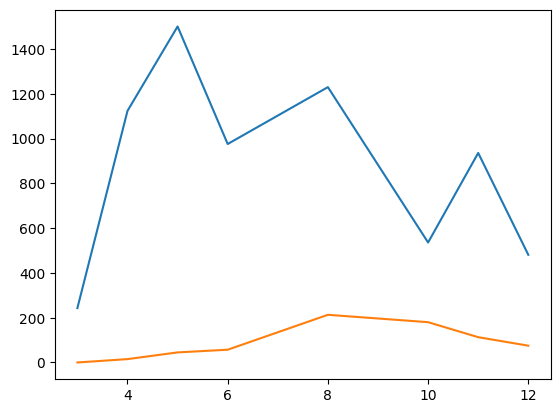

In [11]:
plt.plot(stages,components_hh)
plt.plot(stages,cycles_hh)



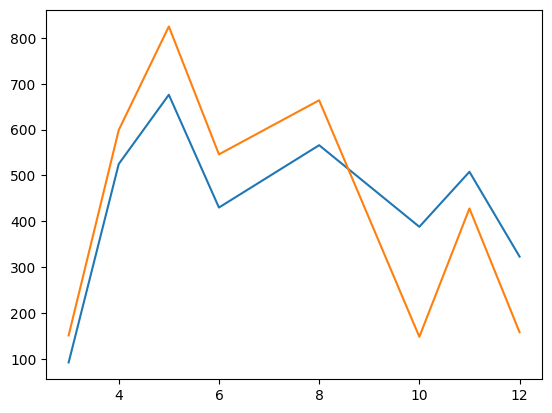

In [13]:
plt.plot(stages,strong_components_hh)
plt.plot(stages,weak_components_hh)

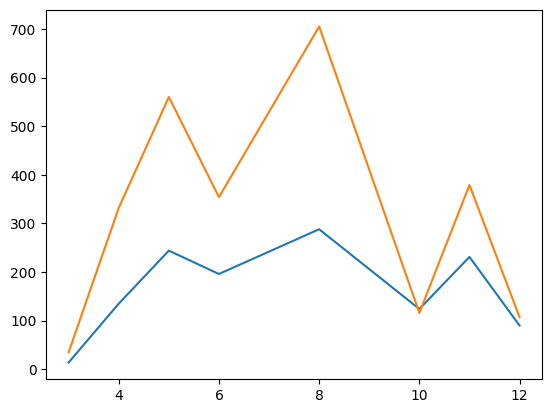

In [17]:
plt.plot(stages,strong_edges_hh)
plt.plot(stages,weak_edges_hh)

In [ ]:
from ripser import ripser
from sklearn import datasets
import scipy

#all = ripser(result["dperm2all"],distance_matrix=True)


<COOrdinate sparse matrix of dtype 'float64'
	with 49 stored elements and shape (9, 9)>
  Coords	Values
  (0, 0)	186.0
  (1, 1)	0.0
  (2, 2)	207.0
  (3, 3)	120.0
  (4, 4)	0.0
  (5, 5)	0.0
  (6, 6)	235.0
  (7, 7)	207.0
  (8, 8)	120.0
  (0, 4)	186.0
  (1, 5)	0.0
  (3, 7)	207.0
  (4, 8)	120.0
  (0, 3)	186.0
  (1, 4)	0.0
  (2, 5)	207.0
  (3, 6)	235.0
  (4, 7)	207.0
  (5, 8)	120.0
  (1, 3)	120.0
  (2, 4)	207.0
  (4, 6)	235.0
  (5, 7)	207.0
  (0, 1)	186.0
  (1, 2)	207.0
  (3, 4)	120.0
  (4, 5)	0.0
  (6, 7)	235.0
  (7, 8)	207.0
  (1, 0)	186.0
  (2, 1)	207.0
  (4, 3)	120.0
  (5, 4)	0.0
  (7, 6)	235.0
  (8, 7)	207.0
  (3, 1)	120.0
  (4, 2)	207.0
  (6, 4)	235.0
  (7, 5)	207.0
  (3, 0)	186.0
  (4, 1)	0.0
  (5, 2)	207.0
  (6, 3)	235.0
  (7, 4)	207.0
  (8, 5)	120.0
  (4, 0)	186.0
  (5, 1)	0.0
  (7, 3)	207.0
  (8, 4)	120.0


In [4]:
def basic_filtering(components,cycles, min_lifespan=30,upper=200,plot=False):

    print(components)
    print(f"Number of components before: {len(components)}")
    comp_filter = [i[1]-i[0]>=min_lifespan for i in components] #filter min lifespan
    comp_filter2 = [i[0]<=upper for i in components] #filter below birth limit
    components = components[np.logical_and(comp_filter,comp_filter2)]

    print(f"Number of components after filtering: {len(components)}")


    print(f"Number of cycles before: {len(cycles)}")
    cycle_filter = [i[1]-i[0]>=min_lifespan for i in cycles] #filter min lifespan
    cycle_filter2 = [i[0]<=upper for i in cycles] #filter below birth limit
    cycles = cycles[np.logical_and(cycle_filter,cycle_filter2)]
    print(f"Number of cycles after filtering: {len(cycles)}")

    if plot:
        plot_diagrams([components,cycles], show=True)
    return([components,cycles])


In [5]:
def component_filtering(components,d1=150,plot=False):
    #d1: difference between strong and weak components

    fild1 = [i[1]<=d1 for i in components]

    weak_components = components[fild1]

    strong_components = components[np.logical_not(fild1)]

    if plot:
        plot_diagrams([weak_components,strong_components], show=True)
    return [len(weak_components),len(strong_components)]


In [6]:
def edge_filtering(components,b1=5,b2=100,plot=False):
    #b1: birth point between components and edges
    #b2: point between weak and strong edges

    filb1 = [i[0]>=b1 for i in components]
    filb2 = [i[0]<=b2 for i in components]

    weak_edges = components[np.logical_and(filb1,filb2)]

    strong_edges = components[np.logical_and(filb1,np.logical_not(filb2))]

    if plot:
        plot_diagrams([weak_edges,strong_edges], show=True)
    return [len(weak_edges),len(strong_edges)]

In [40]:
def level_set_image(image,a):
    newim=np.copy(image)
    for i in range(len(image)):
        for j in range(len(image[0])):
            if image[i,j] >= 255-a:
                newim[i,j] = 255
    return newim

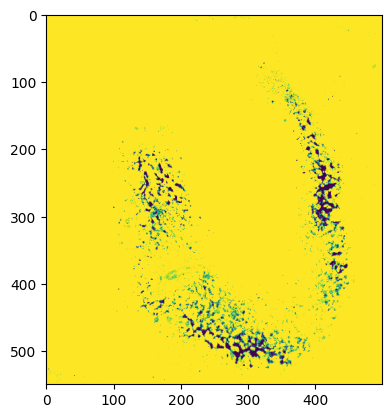

In [42]:
components = result["dgms"][0]

plt.imshow(grey_image)
new_image = level_set_image(grey_image,10)
plt.imshow(new_image)

In [4]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
from sklearn import datasets


all = ripser(test2,distance_matrix=True)
dgms = all["dgms"][0]
plot_diagrams(dgms, show=True)
print(dgms)

NameError: name 'test2' is not defined

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='$r$', ylabel='Feature Number'>)

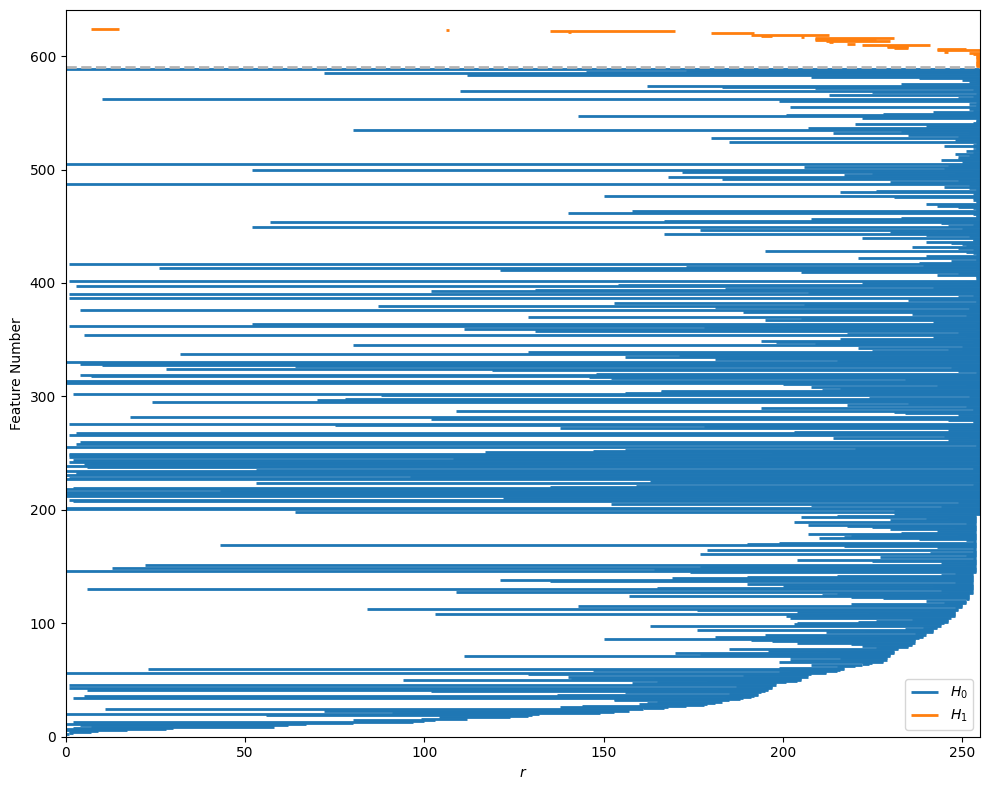

In [23]:
ms.visualise.barcode(result)